# Car Price Prediction - Machine Learning Pipeline

This notebook demonstrates a complete end-to-end Machine Learning pipeline to predict car prices using the dataset `car_price.csv`.

The steps covered are:
1. **Data Loading & Exploratory Data Analysis (EDA)**
2. **Data Cleaning & Preprocessing**
3. **Feature Engineering**
4. **Model Development & Training**
5. **Model Evaluation**

## Step 1: Data Loading & Exploratory Data Analysis (EDA)
We will begin by importing the necessary libraries, loading the dataset, and performing an initial analysis to understand its structure, column types, and statistical properties.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load the dataset
df = pd.read_csv('../data/car_price.csv')

# Display basic information and shape
print(f"Dataset Shape: {df.shape}")
print("\n--- Info ---")
display(df.info())
print("\n--- Head ---")
display(df.head())

Dataset Shape: (301, 9)

--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


None


--- Head ---


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Let's check the descriptive statistics of the numerical features and look for any missing values.

In [3]:
print("--- Summary Statistics ---")
display(df.describe())
display(df.describe().T)

print("\n--- Missing Values ---")
display(df.isnull().sum())

--- Summary Statistics ---


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


,count,mean,std,min,25%,50%,75%,max
Year,301.0,2013.627907,2.891554,2003.00,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,4.661296,5.082812,0.10,0.9,3.6,6.0,35.0
Present_Price,301.0,7.628472,8.642584,0.32,1.2,6.4,9.9,92.6
Driven_kms,301.0,36947.205980,38886.883882,500.00,15000.0,32000.0,48767.0,500000.0
Owner,301.0,0.043189,0.247915,0.00,0.0,0.0,0.0,3.0



--- Missing Values ---


Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

## Step 2 & 3: Data Cleaning, Preprocessing & Feature Engineering
We will define our target variable (usually `price` or similar, depending on the column names present in the dataset) and separate features. We will automatically handle both categorical and numerical columns using an sklearn preprocessing pipeline.

In [4]:
# Identify target and features
# Note: Assumes 'price' is the target column. We will use case-insensitive matching or fallback to the last column.
target_col = [col for col in df.columns if 'price' in col.lower()]
if target_col:
    target = target_col[0]
else:
    # Fallback to the last column if 'price' is not found
    target = df.columns[-1]

print(f"Target column identified: {target}")

X = df.drop(columns=[target])
y = df[target]

# Identify numerical and categorical features
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical features: {num_features}")
print(f"Categorical features: {cat_features}")

# Create Preprocessing Transformers
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)

Target column identified: Selling_Price
Numerical features: ['Year', 'Present_Price', 'Driven_kms', 'Owner']
Categorical features: ['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']


C:\Users\sefim\AppData\Local\Temp\ipykernel_12848\2381965032.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()


## Step 4: Model Training
We split the dataset into training and testing sets, then build a Pipeline containing the preprocessor and a Random Forest Regressor.

In [5]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the full pipeline with a Random Forest Regressor
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train the model
model.fit(X_train, y_train)
print("Model training completed successfully!")

Model training completed successfully!


## Step 5: Model Evaluation
We evaluate our model using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the R-squared ($R^2$) score to measure overall goodness of fit.

--- Model Performance Evaluation ---
Mean Absolute Error (MAE): 0.59
Mean Squared Error (MSE): 0.74
Root Mean Squared Error (RMSE): 0.86
R-squared Score (R2): 0.9677


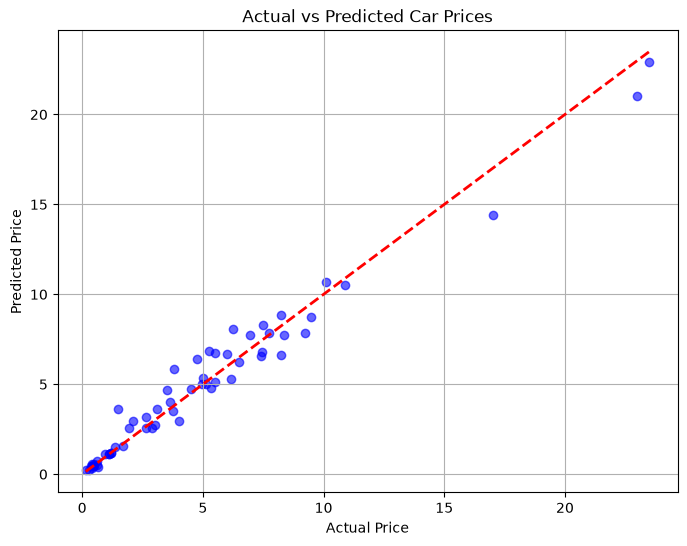

In [6]:
# Generate predictions
y_pred = model.predict(X_test)

# Metrics calculation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Model Performance Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score (R2): {r2:.4f}")

# Plotting predictions vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices')
plt.grid(True)
plt.show()